# Lesson 5 - Dates, Datetimes, and Plotting

When we import data that has a date associated with it, the date often arrives as a *string*. Humans can read date strings like `01-Oct-2016` and understand their order in time, but Python treats them as text until we convert them.

That is why we use date-like objects. A `date` stores a calendar day. A `datetime` stores a calendar day plus a time of day. Once dates are stored this way, Python can sort them, compare them, subtract them, and use them correctly on plot axes.

For one or two dates, we can create `date` and `datetime` objects directly. When dates come from a CSV file, we usually use pandas to convert an entire column at once.


In [ ]:
# Simple date and datetime example
from datetime import datetime, date, timedelta
import pandas as pd

d = date(2026, 6, 9)
dt = datetime(2026, 6, 9, 14, 30)

print(d)
print(dt)


## Converting Date Strings with Pandas

The example above is useful for understanding the difference between `date` and `datetime`, but most real datasets store dates in a column of strings. For that, pandas gives us `pd.to_datetime()`.

`pd.to_datetime()` takes date strings and converts them into pandas datetime values. These behave like dates for sorting, filtering, plotting, and time differences. The `format` argument tells pandas how the text is written. For example, `%d-%b-%Y` means day number, abbreviated month name, and four-digit year.


In [ ]:
# Convert date strings with pandas
date_strings = pd.Series([
    '01-Oct-2025',
    '02-Oct-2025',
    '03-Oct-2025'
])

converted_dates = pd.to_datetime(date_strings, format='%d-%b-%Y')

print(date_strings)
print(converted_dates)


## Use Cases for Dates and Datetimes

The most common reason we use dates and datetimes in this class is for **plotting**. If we have a 365-element vector of data from an automatic weather station and plot it by itself, the x-axis will just be values `0` through `364` (or `1` through `365`, depending on how we make the plot).

If we instead give matplotlib real dates for the x-axis, the plot becomes much easier to read. Date-aware plotting also makes it easier to compare data from multiple sources, especially when those sources have different sampling times.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Synthetic daily data
y = 50 + 20*np.sin(2*np.pi*np.arange(365)/365)

plt.figure(figsize=(10,4))
plt.plot(y)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('365-element array')
plt.show()

In [ ]:
# Correct way with matplotlib

start_date = date(2025, 10, 1)

dates = [
    start_date + timedelta(days=i)
    for i in range(365)
]

y = 50 + 20*np.sin(2*np.pi*np.arange(365)/365)

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(dates, y)

ax.set_title('Automatic date handling')
ax.set_ylabel('Value')

fig.autofmt_xdate()

plt.show()

In [ ]:
# Plotting multiple data sources example

# --- Daily model data ---
start_date = date(2025, 10, 1)

model_dates = [
    start_date + timedelta(days=i)
    for i in range(365)
]

model_swe = (
    300*np.sin(np.pi*np.arange(365)/365)**2
    + np.random.normal(0, 10, 365)
)

# --- Sparse observations ---
obs_dates = [
    date(2025, 11, 15),
    date(2026, 1, 1),
    date(2026, 2, 15),
    date(2026, 4, 1),
    date(2026, 5, 15)
]

obs_swe = [35, 120, 240, 310, 180]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(model_dates, model_swe, label='Model SWE')
ax.scatter(obs_dates, obs_swe, s=60, label='SNOTEL',color='red')

ax.set_ylabel('SWE (mm)')
ax.legend()

fig.autofmt_xdate()

plt.show()

# Activity! Recreate an Image

In this activity, you will use data from one of my papers to recreate the figure below. The figure shows a time series of snow water storage from several model data sources, plus observations from an airborne campaign.

Your goal is not to make a pixel-perfect copy. Focus first on loading the data, converting the dates correctly, and plotting each data source on the right date axis. Once that works, you can improve the colors, line styles, labels, and legend.

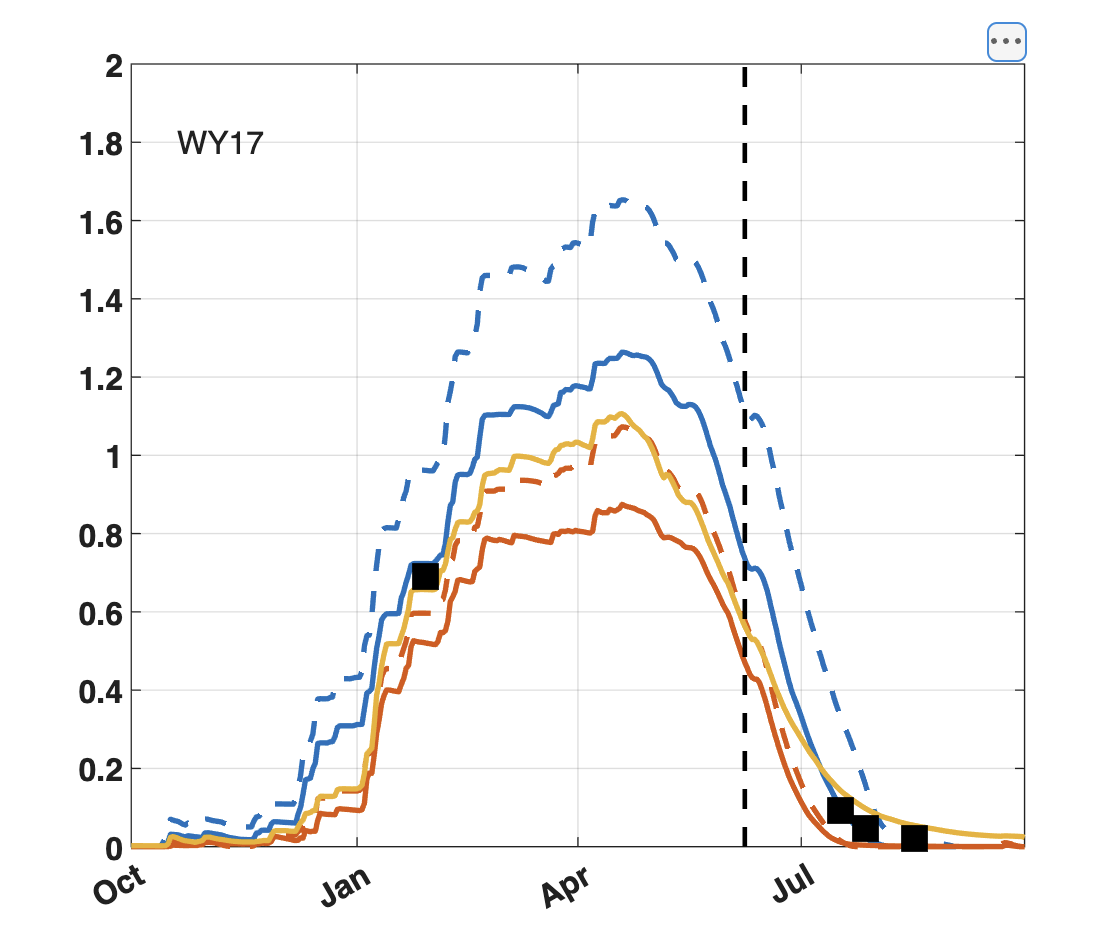

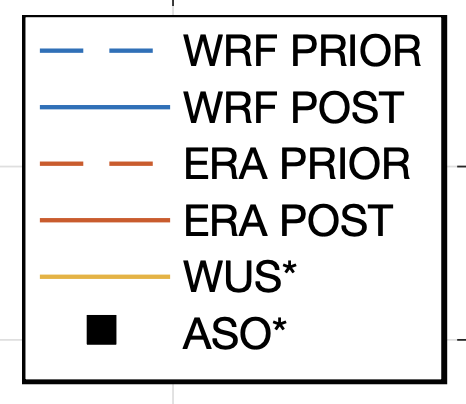


## Step 0 - Data Description

There are four files in the `data` folder:

- `airborne_data.csv`: four airborne observation points, with one date and one SWS value per row
- `model_data_t1.csv`: a 365-day time series with two model estimates
- `model_data_t2.csv`: a 365-day time series with three model estimates
- `snow_off_date.txt`: the snow disappearance date, used for a vertical dashed line

The two model data files cover nearly the same water year. A **water year** starts on October 1 and ends on September 30 of the following calendar year. For example, WY17 runs from October 1, 2016 through September 30, 2017.

The model files do not start on exactly the same date, so inspect the CSV files before plotting.


## Step 1 - Load the Data

Load the datasets as either NumPy arrays or pandas DataFrames. I recommend pandas here because each file has named columns and date strings.

After loading, check the column names and the first few rows so you know which variables you need to plot.


## Step 2 - Convert and Align the Dates

Convert the date columns to Python-friendly date or datetime values. Since we are plotting with matplotlib, I recommend using pandas datetime values or Python `date` objects.

> **Note:** Not all files use the same date format. Check the strings carefully before choosing a format code.

> **Hint:** Use `pd.to_datetime()` to convert each date column. The `format` argument should match the way dates are written in each file.


## Step 3 - Plot the Data

Plot the model data as lines and the airborne observations as points. You do not need to use the exact same colors as the reference figure, but make sure your legend matches what you actually plotted.

> **Note:** The time series datasets do not all cover the exact same date range. Set your x-axis limits to match the start and end dates of `model_data_t2.csv`.


## Step 4 - Extra Credit

- Plot the vertical line representing the snow-off date.
- Label the y-axis as `SWS [km^3]`.
- Add the plot title `Tuolumne Meadows Basin Snow Water Storage [WY17]`.
- Match the color and line styles of the original plot.


In [ ]:
# Activity workspace
# Add your loading, date conversion, and plotting code here.
# If you've run the prior cells, the only library you should need to import is pandas.
# If you haven't, go back and run them first to import the correct libraries.

